# Multi-Intent Parser Benchmark v3

**Goal**: Benchmark multiple methods for splitting a user message into
individual intents / actions.

**Methods benchmarked**:
| # | Name | Description |
|---|------|-------------|
| 1 | `split` | Rule-based regex splitting |
| 2 | `semantic` | Regex split + embedding-based merge/dedup + pronoun resolution |
| 3 | `semantic+merge` | Method 2 + short-fragment merging |
| 4 | `verb-guard-merge` | Split → merge short fragments **only when they carry no verb** |
| 5 | `cjk-verb-guard` | CJK-aware split (고/て suffixes) + verb-guard merge |
| 6 | `spacy-pos` | CJK-aware split + spaCy POS tagger for verb detection (en/ko/jp); vi falls back to verb-list |

**Metrics**:
- **Accuracy** — fraction of messages where predicted action count == ground truth
- **Avg latency** — average wall-clock time per message (seconds)

**Data**: A CSV where each row has a raw user message and the expected
number of intents (`no_actions`).


In [164]:
# !pip install spacy
# !python -m spacy download en_core_web_sm
# !python -m spacy download ko_core_news_sm
# !pip install "spacy[ja]"
# !python -m spacy download ja_core_news_sm

## 1 · Imports

In [83]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import spacy
from sentence_transformers import SentenceTransformer

## 2 · Global Config

**Edit everything here — nothing is hard-coded elsewhere.**

In [84]:
CONFIG = {

    # ── Data ──────────────────────────────────────────────────────────────
    "csv_path":     "multi_intent_test.csv",
    "text_column":  "message",        # column that holds the raw utterance
    "label_column": "no_actions",     # column with ground-truth action count
    "lang_column":  "lang",           # column with language code (e.g. en/vi/ko/jp)

    # ── Rule-based split pattern ───────────────────────────────────────────
    # Pipe-delimited regex alternation used by re.split()
    "split_pattern": (
        r",|;"
        r"| and "
        r"| then "
        r"| also "
        r"| and then "
        # Vietnamese
        r"| và "
        r"| rồi "
        r"| sau đó "
        # Korean
        r"| 그리고 "
        r"| 그리고 나서 "
        r"| 그 다음 "
        # Japanese
        r"| そして "
        r"| それから "
        r"| そのあと "
    ),

    # ── Pronouns (trigger coreference resolution) ─────────────────────────
    "pronouns": [
        # English
        "him", "her", "them", "it", "that", "this", "his", "their",
        # Vietnamese
        "anh ấy", "cô ấy", "ông ấy", "bà ấy", "họ", "nó", "đó",
        # Korean
        "그", "그녀", "그들", "그것",
        # Japanese
        "彼", "彼女", "彼ら", "それ",
    ],

    # ── Intent-bearing verbs (used to decide split vs. merge) ─────────────
    "verbs_en": [
        "open", "close", "play", "stop", "pause",
        "tell", "show", "find", "navigate",
        "turn", "switch", "enable", "disable",
        "unlock", "lock", "check", "search",
        "call", "send", "read",
        "start", "launch",
        "increase", "decrease",
        "set", "change",
    ],
    "verbs_vi": [
        "mở", "đóng", "bật", "tắt",
        "phát", "dừng",
        "kể", "nói",
        "tìm", "kiểm tra",
        "dẫn", "chỉ",
        "gọi", "nhắn",
        "tăng", "giảm",
    ],
    "verbs_ko": [
        "열", "닫", "켜", "꺼",
        "재생", "멈춰",
        "말", "알려",
        "찾", "검색",
        "안내",
        "전화",
    ],
    "verbs_jp": [
        "開け", "閉め",
        "再生", "停止",
        "教え",
        "探",
        "案내",
        "電話",
    ],

    # ── CJK-aware split patterns (method 5) ──────────────────────────────
    # Korean: split on verb-connective suffix 고 (e.g. 열고 → 열 | 고)
    # The pattern keeps the verb stem by splitting AFTER the 고/서 ending.
    # We insert a split boundary after verb-stem+고 sequences.
    # Regex: look for a Hangul character followed by 고/서 then space or end.
    "split_pattern_ko": (
        r"(?<=고)\s+"          # after 고 + whitespace  (열고 음악)
        r"|(?<=서)\s+"         # after 서 + whitespace  (해서 ...)
        r"|(?<=고)(?=[가-힣])" # after 고 directly before next Hangul (no space)
    ),

    # Japanese: split on て-form connectives and Japanese comma
    # 開けて音楽  →  開けて | 音楽
    "split_pattern_jp": (
        r"(?<=て)(?=[ぁ-ん\u30A0-\u30FF\u4E00-\u9FFF])"  # after て before CJK/kana
        r"|(?<=して)(?=[ぁ-ん\u30A0-\u30FF\u4E00-\u9FFF])"
        r"|[、，]"             # Japanese / fullwidth comma
    ),

    # ── Embedding model ───────────────────────────────────────────────────
    "embedding_model": (
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    ),

    # ── spaCy models (method 6) ───────────────────────────────────────────
    # Official models for en/ko/jp; vi falls back to verb-list (no official model).
    # Install before running method 6:
    #   pip install spacy
    #   python -m spacy download en_core_web_sm
    #   python -m spacy download ko_core_news_sm
    #   pip install spacy[ja] && python -m spacy download ja_core_news_sm
    "spacy_models": {
        "en": "en_core_web_sm",
        "ko": "ko_core_news_sm",
        "jp": "ja_core_news_sm",
        "vi": None,             # no official model → falls back to has_verb()
    },

    # ── Semantic thresholds ───────────────────────────────────────────────
    # Cosine similarity above which two consecutive fragments are merged
    "similarity_threshold": 0.8,

    # Fragments with fewer words than this are merged into the previous one
    "min_words_merge": 5,

    # ── Plot style ────────────────────────────────────────────────────────
    "fig_style":      "seaborn-v0_8-whitegrid",
    "bar_color":      "#4C72B0",
    "accent_color":   "#DD8452",
    "fig_width":      10,
    "fig_height":     4,
}

## 3 · Derived Config

In [85]:
# Flat list of all verbs across languages — built once from CONFIG
ALL_VERBS: list[str] = (
    CONFIG["verbs_en"]
    + CONFIG["verbs_vi"]
    + CONFIG["verbs_ko"]
    + CONFIG["verbs_jp"]
)

## 4 · Load Dataset

In [86]:
df = pd.read_csv(CONFIG["csv_path"], encoding="utf-8")

messages:    list[str] = df[CONFIG["text_column"]].tolist()
no_actions:  list[int] = df[CONFIG["label_column"]].tolist()
languages:   list[str] = df[CONFIG["lang_column"]].tolist()

print(f"Loaded {len(messages)} samples.")
print(f"Languages found: {sorted(set(languages))}")
df.head()

Loaded 110 samples.
Languages found: ['en', 'jp', 'ko', 'vi']


,id,message,no_actions,lang
0,1,"Open the trunk, play some rock music and navig...",3,en
1,2,tell me about Micheal Jackson and play a song ...,2,en
2,3,"open the trunk, the right front door, the sunr...",2,en
3,4,"Mở cốp, cửa trước, cửa sau và bật nhạc",2,vi
4,5,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,2,ko


## 5 · Core Helper Functions

In [87]:
def split_basic(text: str, cfg: dict) -> list[str]:
    """
    Step 1 shared by all methods.
    Split *text* on the regex pattern defined in cfg["split_pattern"].
    Returns a list of non-empty stripped fragments.
    """
    return [
        p.strip()
        for p in re.split(cfg["split_pattern"], text)
        if p.strip()
    ]

In [88]:
def has_verb(text: str, verbs: list[str]) -> bool:
    """
    Return True if *text* (lowercased) contains at least one entry
    from *verbs*.  Used to decide whether a fragment carries its own
    intent-bearing verb.
    """
    t = text.lower()
    return any(v in t for v in verbs)

In [89]:
def extract_entity(text: str) -> str | None:
    """
    Heuristic: entity = sequence of capitalized words in *text*.
    Returns the entity string, or None if no capitalized sequence found.
    """
    caps = [w for w in text.split() if w[:1].isupper()]
    return " ".join(caps) if len(caps) >= 2 else None

In [90]:
def resolve_pronoun(text: str, entity: str | None, pronouns: list[str]) -> str:
    """
    If *text* contains a pronoun from *pronouns* and *entity* is known,
    replace the first matching pronoun with *entity*.
    """
    if entity is None:
        return text
    t = text.lower()
    for p in pronouns:
        if p in t:
            return re.sub(p, entity, text, flags=re.IGNORECASE)
    return text

In [91]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two 1-D numpy arrays."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

In [92]:
def spacy_has_verb(text: str, lang: str) -> bool:
    """
    Return True if *text* contains at least one VERB or AUX token according
    to the spaCy POS tagger for *lang*.

    Falls back to has_verb() (verb-list check) when:
    - The spaCy model for *lang* was not loaded (OSError at load time)
    - *lang* is "vi" (no official model)
    - *lang* is not in SPACY_NLPS at all

    Universal POS tags used:
    - VERB  : main verbs  (열다, 開ける, open, mở)
    - AUX   : auxiliaries (있다, する, will, đã)
    """
    nlp = SPACY_NLPS.get(lang)
    if nlp is None:
        # Graceful fallback — use the original verb-list method
        return has_verb(text, ALL_VERBS)
    doc = nlp(text)
    return any(token.pos_ in ("VERB", "AUX") for token in doc)

In [93]:
# Unicode block ranges used for language detection
_RE_HANGUL  = re.compile(r"[\uAC00-\uD7A3\u1100-\u11FF\u3130-\u318F]")
_RE_HIRAGANA = re.compile(r"[\u3040-\u309F\u30A0-\u30FF]")


def detect_lang(text: str) -> str:
    """
    Heuristic language detection based on Unicode character blocks.
    Returns one of: 'ko', 'jp', 'other'.

    Korean (Hangul) and Japanese (Hiragana / Katakana) are the two scripts
    that need CJK-aware splitting; everything else falls through to the
    standard regex split.

    Detection is intentionally lightweight — a single character is enough
    to identify the script.
    """
    if _RE_HANGUL.search(text):
        return "ko"
    if _RE_HIRAGANA.search(text):
        return "jp"
    return "other"

In [94]:
def split_cjk_aware(text: str, cfg: dict) -> list[str]:
    """
    Language-aware tokenisation for method 5.

    For Korean and Japanese the standard split_basic often returns a single
    fragment because those languages use verb-connective suffixes (고, て)
    rather than standalone conjunction words.

    Algorithm
    ---------
    1. Detect script (Korean / Japanese / other).
    2a. Korean  : split on cfg["split_pattern_ko"]  (고/서 verb endings)
                  then also split on the standard pattern (handles 그리고 etc.)
    2b. Japanese: split on cfg["split_pattern_jp"]  (て-form + 、)
                  then also split on the standard pattern (そして etc.)
    2c. Other   : fall back to split_basic (unchanged behaviour).
    3. Strip and drop empty fragments.

    Note: CJK splits are applied *first*, then the standard pattern is applied
    to each resulting fragment, so both levels of splitting cooperate.
    """
    lang = detect_lang(text)

    if lang == "ko":
        primary = cfg["split_pattern_ko"]
    elif lang == "jp":
        primary = cfg["split_pattern_jp"]
    else:
        return split_basic(text, cfg)

    # Primary CJK split
    rough_parts = [p.strip() for p in re.split(primary, text) if p.strip()]

    # Secondary standard split on each rough fragment (catches 그리고, そして …)
    final = []
    for part in rough_parts:
        sub = split_basic(part, cfg)
        final.extend(sub)

    return [p for p in final if p]

## 6 · Load Embedding Model

In [95]:
print("Loading embedding model …")
_t = time.time()
embed_model = SentenceTransformer(CONFIG["embedding_model"])
print(f"Done in {time.time() - _t:.1f}s")

Loading embedding model …


/home/mrzaizai2k/anaconda3/envs/routing/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Done in 4.5s


## 6b · Load spaCy Models (method 6)

We load one spaCy pipeline per language.  Each model is loaded **once** here
and stored in `SPACY_NLPS` so method 6 can reuse them without reloading.

Vietnamese has no official spaCy model, so `SPACY_NLPS["vi"]` is `None`
and the method falls back to the existing `has_verb()` list check.

**Install commands** (run once in your environment):
```bash
pip install spacy
python -m spacy download en_core_web_sm
python -m spacy download ko_core_news_sm
pip install "spacy[ja]"
python -m spacy download ja_core_news_sm
```

In [96]:
SPACY_NLPS: dict[str, object] = {}

for _lang, _model_name in CONFIG["spacy_models"].items():
    if _model_name is None:
        SPACY_NLPS[_lang] = None
        print(f"  [{_lang}] no spaCy model configured — will use verb-list fallback")
        continue
    try:
        _t = time.time()
        SPACY_NLPS[_lang] = spacy.load(
            _model_name,
            # Load only the tagger for speed — skip parser, NER, lemmatizer
            disable=["parser", "ner", "lemmatizer", "attribute_ruler"],
        )
        print(f"  [{_lang}] loaded '{_model_name}' in {time.time() - _t:.1f}s")
    except OSError:
        SPACY_NLPS[_lang] = None
        print(f"  [{_lang}] model '{_model_name}' not found — run: "
              f"python -m spacy download {_model_name}")

print("spaCy models ready.")

  [en] loaded 'en_core_web_sm' in 0.3s
  [ko] loaded 'ko_core_news_sm' in 0.6s
  [jp] loaded 'ja_core_news_sm' in 0.1s
  [vi] no spaCy model configured — will use verb-list fallback
spaCy models ready.


## 7 · Parser Methods

Each method has the **same signature**:
```python
def methodN(text: str, cfg: dict) -> list[str]
```
This makes them trivially swappable inside the benchmark runner.

In [97]:
def method1_split(text: str, cfg: dict) -> list[str]:
    """
    Method 1 — Rule-based split only.

    Algorithm:
        1. Apply regex split on conjunctions / punctuation.

    Pros : fast, zero dependencies beyond regex.
    Cons : no handling of pronouns, short fragments, or semantic coherence.
    """
    return split_basic(text, cfg)

In [98]:
def method2_semantic(text: str, cfg: dict) -> list[str]:
    """
    Method 2 — Regex split + semantic merge + pronoun resolution.

    Algorithm:
        1. Split on conjunctions (same as method 1).
        2. Encode fragments with a multilingual sentence-transformer.
        3. Walk fragments left-to-right:
           a. Resolve pronouns using the last known entity.
           b. If both the new and previous fragment have their own verbs
              → keep separate (two distinct intents).
           c. Else if cosine similarity to previous fragment is above
              threshold → merge into previous (continuation of same intent).
           d. Otherwise → keep separate.

    Pros : handles pronoun coreference, avoids spurious splits.
    Cons : requires the embedding model; slower than method 1.
    """
    parts = split_basic(text, cfg)
    if len(parts) <= 1:
        return parts

    embeddings = embed_model.encode(parts)       # shape (n, dim)
    result      = [parts[0]]
    last_entity = extract_entity(parts[0])

    for i in range(1, len(parts)):
        fragment = parts[i]

        # --- coreference resolution ---
        entity = extract_entity(fragment)
        if entity:
            last_entity = entity
        else:
            fragment = resolve_pronoun(
                fragment, last_entity, cfg["pronouns"]
            )

        sim       = cosine_sim(embeddings[i], embeddings[i - 1])
        new_verb  = has_verb(fragment,   ALL_VERBS)
        prev_verb = has_verb(result[-1], ALL_VERBS)

        if new_verb and prev_verb:
            # Both fragments carry their own intent verb → separate intents
            result.append(fragment)
        elif sim > cfg["similarity_threshold"]:
            # Semantically similar → merge as continuation
            result[-1] += ", " + fragment
        else:
            result.append(fragment)

    return result

In [99]:
def _merge_short_fragments(parts: list[str], cfg: dict) -> list[str]:
    """
    Post-processing step shared by method 3.
    Any fragment shorter than cfg["min_words_merge"] words is appended
    to the previous fragment instead of being kept separate.
    """
    if not parts:
        return parts
    result = [parts[0]]
    for p in parts[1:]:
        if len(p.split()) < cfg["min_words_merge"]:
            result[-1] += " " + p
        else:
            result.append(p)
    return result

In [100]:
def method3_semantic_merge(text: str, cfg: dict) -> list[str]:
    """
    Method 3 — Method 2 + short-fragment merging.

    Algorithm:
        1. Run method 2 (semantic split + pronoun resolution).
        2. Merge any fragment that is shorter than cfg["min_words_merge"]
           into the preceding fragment.

    Pros : cleans up dangling one-word fragments (e.g. "it", "that").
    Cons : slightly more opinionated; may over-merge in some edge cases.
    """
    parts = method2_semantic(text, cfg)
    if len(parts) <= 1:
        return parts
    return _merge_short_fragments(parts, cfg)

In [101]:
def method4_verb_guard_merge(text: str, cfg: dict) -> list[str]:
    """
    Method 4 — Verb-guarded merge.

    Core idea
    ---------
    After the initial regex split, walk through fragments and decide
    whether each one deserves to be its own intent:

    * If a fragment is **short** (< cfg["min_words_merge"] words)
      AND **has no verb**  ->  it carries no independent intent, so
      append it to the previous fragment (merge).

    * If a fragment **has a verb**  ->  it carries its own intent,
      so always keep it separate, regardless of length.

    * If a fragment is **long but has no verb**  ->  keep it separate
      (likely a noun phrase object of the previous intent; merging
      would change meaning).

    Purely rule-based — no embeddings needed — so it is fast.

    Algorithm
    ---------
    1. Split on conjunctions / punctuation  (same as method 1).
    2. For each fragment after the first:
       a. short AND no verb  ->  merge into previous  (dangling object)
       b. has verb           ->  keep as new intent   (explicit action)
       c. long  AND no verb  ->  keep as new intent   (noun phrase)

    Pros : fast (no embeddings), principled verb-first decision.
    Cons : depends entirely on the verb list; unknown verbs may cause
           false merges on short verbless fragments that are real intents.
    """
    parts = split_basic(text, cfg)
    if len(parts) <= 1:
        return parts

    result = [parts[0]]

    for fragment in parts[1:]:
        is_short          = len(fragment.split()) < cfg["min_words_merge"]
        fragment_has_verb = has_verb(fragment, ALL_VERBS)

        if is_short and not fragment_has_verb:
            # Short + no verb  ->  dangling qualifier, merge into previous
            result[-1] += " " + fragment
        else:
            # Has verb (any length)  OR  long noun phrase  ->  own intent
            result.append(fragment)

    return result

In [102]:
def method5_cjk_verb_guard(text: str, cfg: dict) -> list[str]:
    """
    Method 5 — CJK-aware split + verb-guarded merge.

    Root cause addressed
    --------------------
    Methods 1–4 all rely on split_basic which splits on standalone
    conjunction words (그리고, そして, and, và …).  Korean and Japanese
    instead express coordination through verb-connective suffixes:

      Korean : 열고  (open-AND)   틀고  (play-AND)   걸고  (call-AND)
      Japanese: 開けて (open-AND)  流して (play-AND)  案内して (navigate-AND)

    These suffixes are glued directly to the verb stem with no space,
    so the standard split pattern never fires and the whole sentence
    stays as one fragment.

    Algorithm
    ---------
    1. **CJK-aware split** via split_cjk_aware():
       - Korean  → split after 고/서 verb endings + standard pattern
       - Japanese → split after て-form connectives + 、 + standard pattern
       - Other   → identical to split_basic (no regression on en/vi)
    2. **Verb-guarded merge** (same logic as method 4):
       - short AND no verb  →  merge into previous  (dangling object)
       - has verb           →  keep as separate intent
       - long AND no verb   →  keep as separate intent

    This means en/vi behaviour is identical to method 4 (no regression),
    while ko/jp now get correct multi-intent splitting.

    Pros : fixes ko/jp without embeddings; fast; no regression on en/vi.
    Cons : CJK split patterns may over-split in rare cases where 고/て
           appears as a non-connective ending (e.g. inside a quoted name).
    """
    parts = split_cjk_aware(text, cfg)
    if len(parts) <= 1:
        return parts

    result = [parts[0]]

    for fragment in parts[1:]:
        is_short          = len(fragment.split()) < cfg["min_words_merge"]
        fragment_has_verb = has_verb(fragment, ALL_VERBS)

        if is_short and not fragment_has_verb:
            result[-1] += " " + fragment
        else:
            result.append(fragment)

    return result

In [103]:
def method6_spacy_pos(text: str, cfg: dict) -> list[str]:
    """
    Method 6 — CJK-aware split + spaCy POS-based verb detection.

    Problem with methods 1–5
    ------------------------
    All prior methods use a hand-crafted verb list to decide whether a
    fragment carries an intent.  This works well for English and Vietnamese
    but is brittle for Korean and Japanese because:

    1. Korean / Japanese verbs are highly inflected — the same verb root
       appears in dozens of surface forms (열다/열어/열고/열면/여세요 …).
       A fixed list only covers a fraction of these forms.
    2. Even where the list verb is present, the CJK split (method 5) may
       produce fragments where the verb stem is still partially embedded.

    spaCy solution
    --------------
    spaCy's trained POS taggers assign Universal POS tags to each token after
    proper morphological segmentation:

    - Korean  (ko_core_news_sm)  — rule-based tokenizer, trained tagger
    - Japanese(ja_core_news_sm)  — SudachiPy tokenizer, trained tagger
    - English (en_core_web_sm)   — standard tokenizer + tagger
    - Vietnamese                 — no official model → falls back to has_verb()

    Universal tags used: VERB (open, 열다, 開ける, mở) and AUX (있다, する).

    Algorithm
    ---------
    1. Detect language via detect_lang().
    2. Apply CJK-aware split (split_cjk_aware) for ko/jp, split_basic otherwise.
    3. Walk fragments left-to-right:
       a. Detect verbs using spacy_has_verb() — real POS tags for en/ko/jp,
          verb-list fallback for vi.
       b. short AND no verb  →  merge into previous  (dangling object)
       c. has verb           →  keep as new intent
       d. long  AND no verb  →  keep as new intent   (noun phrase)

    Pros : handles inflected verb forms in ko/jp that the verb list misses;
           no hand-crafted verb list required for en/ko/jp.
    Cons : requires spaCy + language models installed; slower than methods 4–5
           due to POS inference per fragment; vi still uses verb-list fallback.
    """
    lang  = detect_lang(text)
    parts = split_cjk_aware(text, cfg)

    if len(parts) <= 1:
        return parts

    result = [parts[0]]

    for fragment in parts[1:]:
        is_short          = len(fragment.split()) < cfg["min_words_merge"]
        fragment_has_verb = spacy_has_verb(fragment, lang)

        if is_short and not fragment_has_verb:
            result[-1] += " " + fragment
        else:
            result.append(fragment)

    return result

## 8 · Evaluation Helpers

In [104]:
def compute_accuracy(results: list[list[str]], ground_truth: list[int]) -> float:
    """
    Fraction of samples where len(predicted_intents) == ground_truth count.
    """
    correct = sum(
        1 for pred, gt in zip(results, ground_truth) if len(pred) == gt
    )
    return correct / len(results)

In [105]:
def compute_per_class_accuracy(
    results:      list[list[str]],
    ground_truth: list[int],
) -> pd.DataFrame:
    """
    Per-action-count breakdown: for each unique value in ground_truth,
    report how many samples exist and what fraction were predicted correctly.
    Useful for spotting where a method struggles (e.g. 3-intent messages).
    """
    records = []
    for pred, gt in zip(results, ground_truth):
        records.append({"gt": gt, "correct": int(len(pred) == gt)})
    tmp = pd.DataFrame(records)
    summary = (
        tmp.groupby("gt")["correct"]
        .agg(total="count", correct="sum")
        .assign(accuracy=lambda x: x["correct"] / x["total"])
        .reset_index()
        .rename(columns={"gt": "n_actions"})
    )
    return summary

In [106]:
def compute_error_distribution(
    results:      list[list[str]],
    ground_truth: list[int],
) -> pd.Series:
    """
    Distribution of (predicted_count - ground_truth_count).
    0 → perfect, positive → over-split, negative → under-split.
    """
    errors = [len(pred) - gt for pred, gt in zip(results, ground_truth)]
    return pd.Series(errors).value_counts().sort_index()

In [107]:
def compute_per_lang_accuracy(
    results:      list[list[str]],
    ground_truth: list[int],
    langs:        list[str],
) -> pd.DataFrame:
    """
    Per-language accuracy breakdown.

    For each unique language code in *langs*, reports:
      - total   : number of samples in that language
      - correct : number of samples predicted correctly
      - accuracy: fraction correct

    Parameters
    ----------
    results      : list of predicted intent lists (from run_benchmark)
    ground_truth : list of expected action counts
    langs        : list of language codes, one per sample (e.g. "en", "vi")

    Returns
    -------
    DataFrame with columns [lang, total, correct, accuracy], sorted by lang.
    """
    records = [
        {"lang": lg, "correct": int(len(pred) == gt)}
        for pred, gt, lg in zip(results, ground_truth, langs)
    ]
    tmp = pd.DataFrame(records)
    summary = (
        tmp.groupby("lang")["correct"]
        .agg(total="count", correct="sum")
        .assign(accuracy=lambda x: x["correct"] / x["total"])
        .reset_index()
        .sort_values("lang")
        .reset_index(drop=True)
    )
    return summary

## 9 · Benchmark Runner

In [108]:
def run_benchmark(
    func:         "callable",
    name:         str,
    cfg:          dict,
    messages:     list[str],
    ground_truth: list[int],
    langs:        list[str] | None = None,
    verbose:      bool = True,
) -> dict:
    """
    Run *func* on every message, measure wall-clock time, compute metrics,
    print a summary, and return a result dict.

    Parameters
    ----------
    func         : parser function with signature func(text, cfg) -> list[str]
    name         : display name for this method
    cfg          : CONFIG dict passed through to func
    messages     : list of raw utterances
    ground_truth : expected action counts (one per message)
    langs        : optional list of language codes (one per message);
                   when provided, per-language accuracy is computed
    verbose      : print summary to stdout

    Returns
    -------
    dict with keys: name, results, avg_time_ms, accuracy, per_class,
                    errors, per_lang (None if langs not provided)
    """
    results   = []
    latencies = []

    for msg in messages:
        t0 = time.perf_counter()
        r  = func(msg, cfg)
        t1 = time.perf_counter()
        results.append(r)
        latencies.append((t1 - t0) * 1000)   # ms

    avg_ms    = float(np.mean(latencies))
    p50_ms    = float(np.percentile(latencies, 50))
    p95_ms    = float(np.percentile(latencies, 95))
    acc       = compute_accuracy(results, ground_truth)
    per_class = compute_per_class_accuracy(results, ground_truth)
    errors    = compute_error_distribution(results, ground_truth)
    per_lang  = (
        compute_per_lang_accuracy(results, ground_truth, langs)
        if langs is not None else None
    )

    if verbose:
        sep = "─" * 48
        print(sep)
        print(f"  Method   : {name}")
        print(f"  Accuracy : {acc:.1%}  ({int(acc * len(messages))}/{len(messages)})")
        print(f"  Avg time : {avg_ms:.2f} ms/msg")
        print(f"  p50      : {p50_ms:.2f} ms  |  p95 : {p95_ms:.2f} ms")
        if per_lang is not None:
            for _, row in per_lang.iterrows():
                print(f"    [{row['lang']}] {row['accuracy']:.1%}  (n={int(row['total'])})")
        print(sep)

    return {
        "name":        name,
        "results":     results,
        "avg_time_ms": avg_ms,
        "p50_ms":      p50_ms,
        "p95_ms":      p95_ms,
        "accuracy":    acc,
        "per_class":   per_class,
        "errors":      errors,
        "per_lang":    per_lang,
        "latencies":   latencies,
    }

## 10 · Plotting Helpers

In [109]:
def _apply_style(cfg: dict) -> None:
    """Apply matplotlib style from config (called once per plot)."""
    try:
        plt.style.use(cfg["fig_style"])
    except OSError:
        pass   # fall back gracefully if the style name is unavailable

In [110]:
def plot_single_result(result: dict, cfg: dict) -> None:
    """
    Two-panel chart for one method:
      Left  — avg latency (ms)
      Right — accuracy (%)
    """
    _apply_style(cfg)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(cfg["fig_width"], cfg["fig_height"]),
    )
    fig.suptitle(result["name"], fontsize=14, fontweight="bold")

    # Latency panel
    axes[0].bar(
        ["avg", "p50", "p95"],
        [result["avg_time_ms"], result["p50_ms"], result["p95_ms"]],
        color=[cfg["bar_color"], cfg["bar_color"], cfg["accent_color"]],
        edgecolor="white", linewidth=0.8,
    )
    axes[0].set_title("Latency (ms)")
    axes[0].set_ylabel("ms / message")
    for bar in axes[0].patches:
        axes[0].annotate(
            f"{bar.get_height():.2f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=10,
        )

    # Accuracy panel
    axes[1].bar(
        ["accuracy"],
        [result["accuracy"] * 100],
        color=cfg["bar_color"],
        edgecolor="white", linewidth=0.8,
    )
    axes[1].set_ylim(0, 100)
    axes[1].set_title("Accuracy (%)")
    axes[1].set_ylabel("% correct")
    axes[1].annotate(
        f"{result['accuracy']:.1%}",
        (0, result["accuracy"] * 100),
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

In [111]:
def plot_error_distribution(result: dict, cfg: dict) -> None:
    """
    Bar chart of (predicted − ground_truth) error distribution for one method.
    0 = perfect, positive = over-split, negative = under-split.
    """
    _apply_style(cfg)
    err = result["errors"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.6, cfg["fig_height"]))
    colors = [
        cfg["bar_color"] if idx == 0 else cfg["accent_color"]
        for idx in err.index
    ]
    ax.bar(err.index.astype(str), err.values, color=colors, edgecolor="white")
    ax.set_title(f"{result['name']} — error distribution  (pred − truth)")
    ax.set_xlabel("predicted_count − ground_truth_count")
    ax.set_ylabel("# messages")
    ax.axvline(x=err.index.tolist().index(0) if 0 in err.index else -1,
               color="green", linestyle="--", linewidth=1.2, label="perfect")
    plt.tight_layout()
    plt.show()

In [112]:
def plot_per_class(result: dict, cfg: dict) -> None:
    """
    Per-action-count accuracy breakdown — shows where a method struggles.
    """
    _apply_style(cfg)
    pc = result["per_class"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.7, cfg["fig_height"]))
    ax.bar(
        pc["n_actions"].astype(str),
        pc["accuracy"] * 100,
        color=cfg["bar_color"], edgecolor="white",
    )
    ax.set_ylim(0, 110)
    ax.set_title(f"{result['name']} — accuracy by n_actions")
    ax.set_xlabel("ground-truth action count")
    ax.set_ylabel("accuracy (%)")
    for _, row in pc.iterrows():
        ax.annotate(
            f"{row['accuracy']:.0%}\n(n={int(row['total'])})",
            (str(int(row["n_actions"])), row["accuracy"] * 100 + 1),
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

In [113]:
def plot_comparison(all_results: list[dict], cfg: dict) -> None:
    """
    Side-by-side comparison of all methods: accuracy + avg latency.
    Call this after all methods have been benchmarked.
    """
    _apply_style(cfg)

    names = [r["name"]        for r in all_results]
    accs  = [r["accuracy"]*100 for r in all_results]
    lats  = [r["avg_time_ms"] for r in all_results]

    fig, axes = plt.subplots(1, 2, figsize=(cfg["fig_width"], cfg["fig_height"]))
    fig.suptitle("Method Comparison", fontsize=15, fontweight="bold")

    x = range(len(names))

    axes[0].bar(x, accs,  color=cfg["bar_color"], edgecolor="white")
    axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
    axes[0].set_ylim(0, 110); axes[0].set_title("Accuracy (%)")
    for xi, v in zip(x, accs):
        axes[0].text(xi, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

    axes[1].bar(x, lats, color=cfg["accent_color"], edgecolor="white")
    axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
    axes[1].set_title("Avg Latency (ms / message)")
    for xi, v in zip(x, lats):
        axes[1].text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

In [114]:
def plot_per_lang(result: dict, cfg: dict) -> None:
    """
    Grouped bar chart: per-language accuracy for a single method.
    Skipped silently if result["per_lang"] is None.
    """
    if result["per_lang"] is None:
        print(f"[{result['name']}] per_lang not available — pass langs= to run_benchmark.")
        return

    _apply_style(cfg)
    pl = result["per_lang"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.7, cfg["fig_height"]))
    bars = ax.bar(
        pl["lang"],
        pl["accuracy"] * 100,
        color=cfg["bar_color"], edgecolor="white",
    )
    ax.set_ylim(0, 115)
    ax.set_title(f"{result['name']} — accuracy by language")
    ax.set_xlabel("language")
    ax.set_ylabel("accuracy (%)")
    for bar, (_, row) in zip(bars, pl.iterrows()):
        ax.annotate(
            f"{row['accuracy']:.0%}\n(n={int(row['total'])})",
            (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

In [115]:
def plot_lang_comparison(all_results: list[dict], cfg: dict) -> None:
    """
    Grouped bar chart comparing all methods side-by-side for each language.
    One group of bars per language, one bar per method.
    """
    # Collect all lang codes that appear in any result
    all_langs = sorted({
        row["lang"]
        for r in all_results
        if r["per_lang"] is not None
        for _, row in r["per_lang"].iterrows()
    })
    if not all_langs:
        print("No per-lang data available.")
        return

    _apply_style(cfg)
    n_methods = len(all_results)
    n_langs   = len(all_langs)
    x         = np.arange(n_langs)
    bar_width  = 0.8 / n_methods

    # Build a color palette — interpolate between bar_color and accent_color
    palette = [
        cfg["bar_color"],
        cfg["accent_color"],
        "#55A868",   # green
        "#C44E52",   # red
    ][:n_methods]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"], cfg["fig_height"] * 1.2))
    fig.suptitle(
        "Per-language accuracy — all methods",
        fontsize=14, fontweight="bold",
    )

    for i, (r, color) in enumerate(zip(all_results, palette)):
        if r["per_lang"] is None:
            continue
        pl = r["per_lang"].set_index("lang")
        accs = [
            pl.loc[lg, "accuracy"] * 100 if lg in pl.index else 0.0
            for lg in all_langs
        ]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        bars = ax.bar(
            x + offset, accs,
            width=bar_width,
            label=r["name"],
            color=color,
            edgecolor="white",
        )
        for bar, v in zip(bars, accs):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{v:.0f}%",
                    ha="center", va="bottom", fontsize=7,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(all_langs)
    ax.set_ylim(0, 115)
    ax.set_xlabel("language")
    ax.set_ylabel("accuracy (%)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## 11 · Method Registry

**Add new methods here** — the rest of the notebook picks them up automatically.

In [116]:
METHODS = [
    {"func": method1_split,           "name": "split"},
    {"func": method2_semantic,        "name": "semantic"},
    {"func": method3_semantic_merge,  "name": "semantic+merge"},
    {"func": method4_verb_guard_merge,"name": "verb-guard-merge"},
    {"func": method5_cjk_verb_guard,  "name": "cjk-verb-guard"},
    {"func": method6_spacy_pos,       "name": "spacy-pos"},
    # ── add more entries here ──────────────────────────────────────────
]

## 12 · Run: Method 1 — split

In [117]:
result1 = run_benchmark(
    func         = METHODS[0]["func"],
    name         = METHODS[0]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : split
  Accuracy : 37.3%  (41/110)
  Avg time : 0.00 ms/msg
  p50      : 0.00 ms  |  p95 : 0.00 ms
    [en] 61.8%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 62.5%  (n=32)
────────────────────────────────────────────────


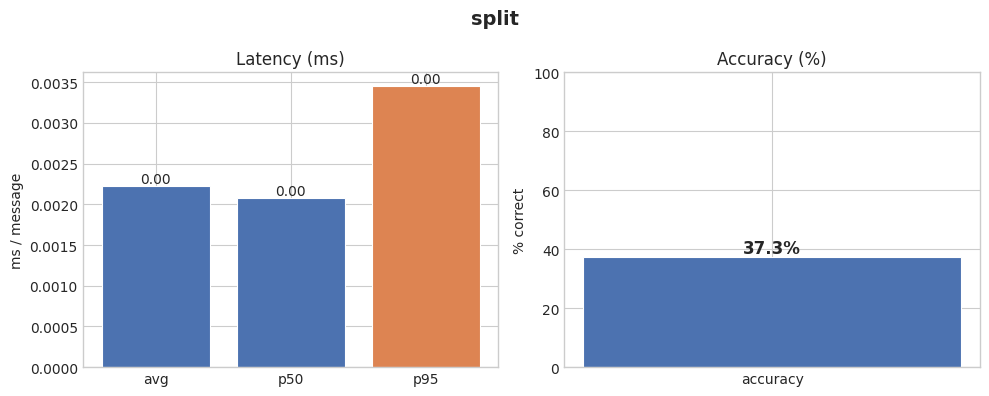

In [118]:
plot_single_result(result1, CONFIG)

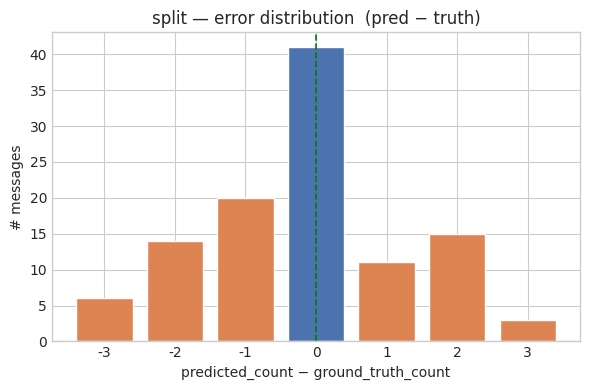

In [119]:
plot_error_distribution(result1, CONFIG)

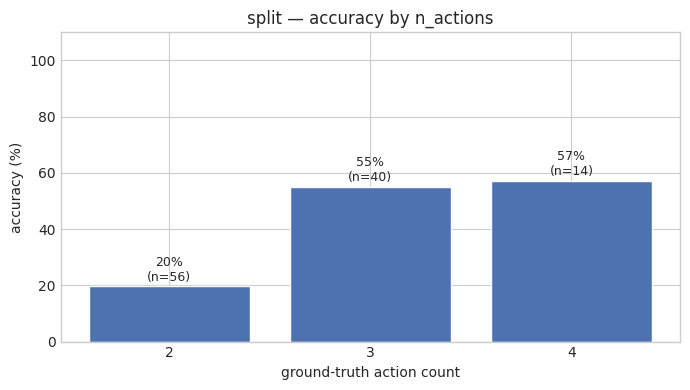

In [120]:
plot_per_class(result1, CONFIG)

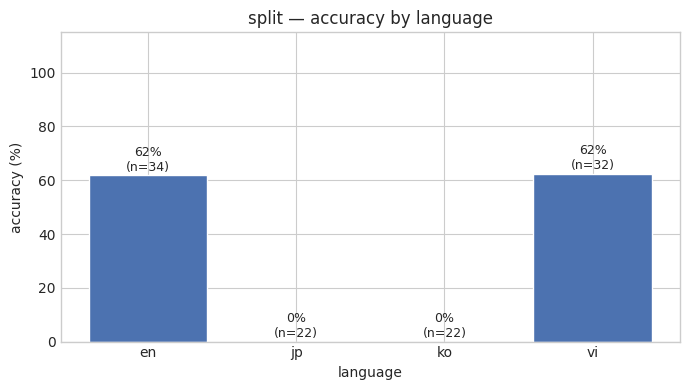

In [121]:
plot_per_lang(result1, CONFIG)

## 13 · Run: Method 2 — semantic

In [122]:
result2 = run_benchmark(
    func         = METHODS[1]["func"],
    name         = METHODS[1]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : semantic
  Accuracy : 37.3%  (41/110)
  Avg time : 9.08 ms/msg
  p50      : 12.07 ms  |  p95 : 19.49 ms
    [en] 61.8%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 62.5%  (n=32)
────────────────────────────────────────────────


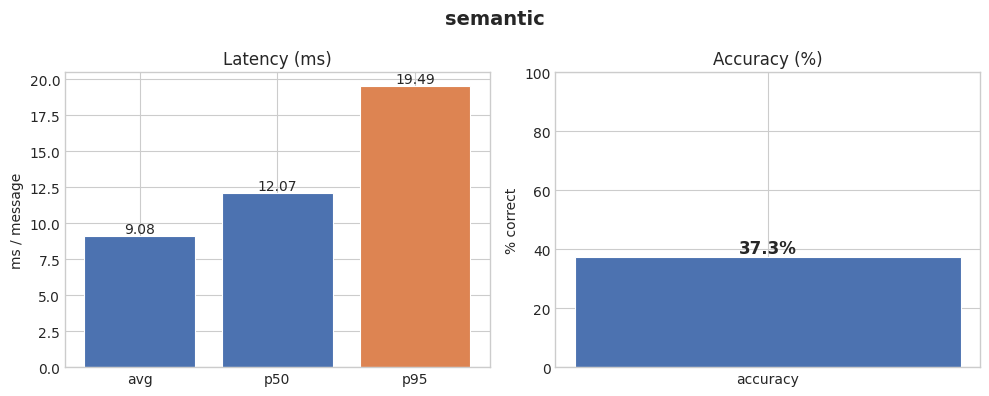

In [123]:
plot_single_result(result2, CONFIG)

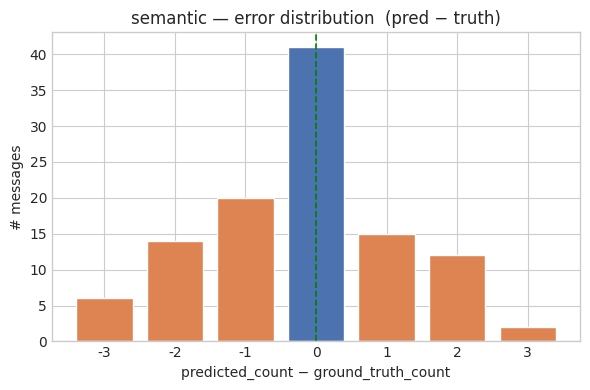

In [124]:
plot_error_distribution(result2, CONFIG)

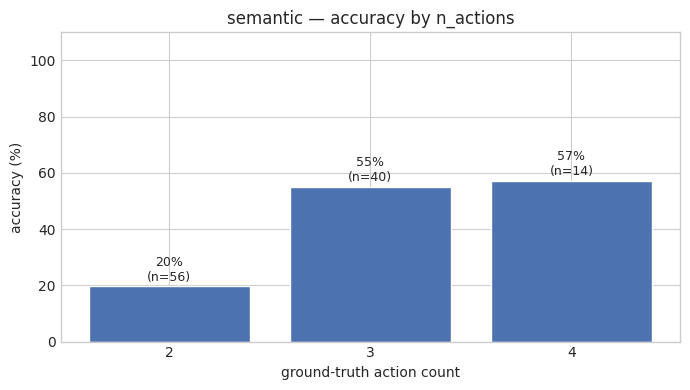

In [125]:
plot_per_class(result2, CONFIG)

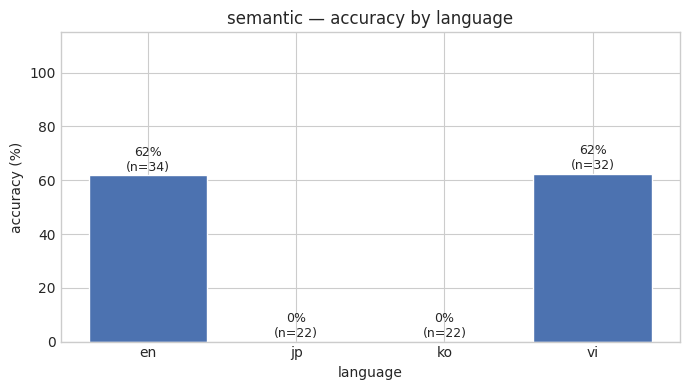

In [126]:
plot_per_lang(result2, CONFIG)

## 14 · Run: Method 3 — semantic + merge

In [127]:
result3 = run_benchmark(
    func         = METHODS[2]["func"],
    name         = METHODS[2]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : semantic+merge
  Accuracy : 9.1%  (10/110)
  Avg time : 9.00 ms/msg
  p50      : 11.20 ms  |  p95 : 19.24 ms
    [en] 14.7%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 15.6%  (n=32)
────────────────────────────────────────────────


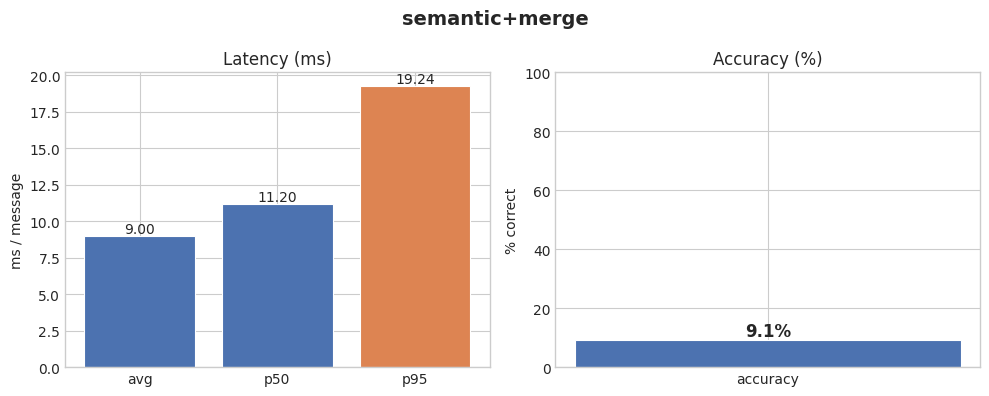

In [128]:
plot_single_result(result3, CONFIG)

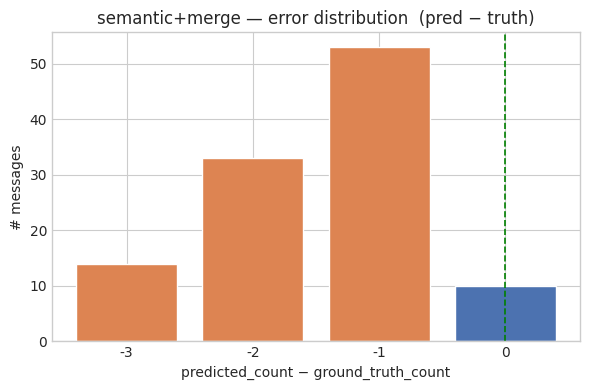

In [129]:
plot_error_distribution(result3, CONFIG)

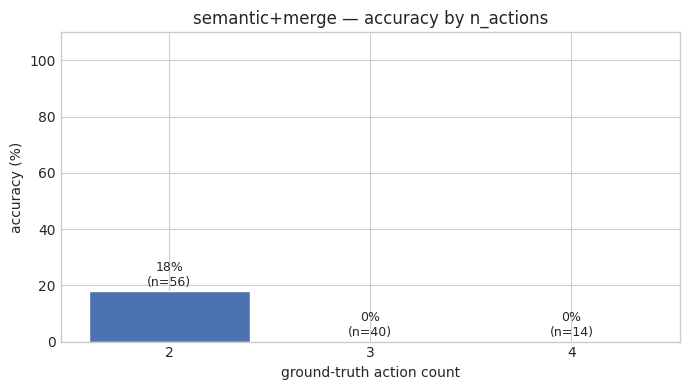

In [130]:
plot_per_class(result3, CONFIG)

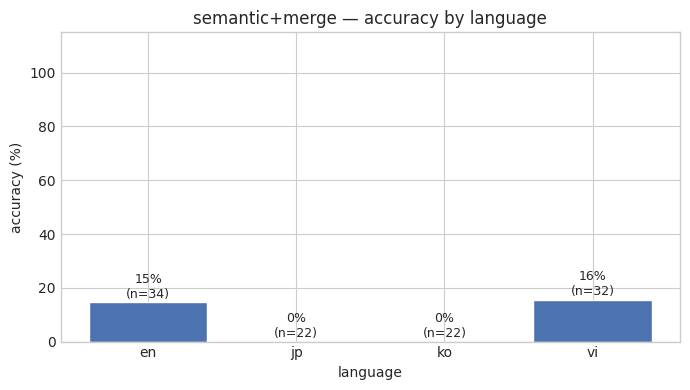

In [131]:
plot_per_lang(result3, CONFIG)

## 15 · Run: Method 4 — verb-guard-merge

In [132]:
result4 = run_benchmark(
    func         = METHODS[3]["func"],
    name         = METHODS[3]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : verb-guard-merge
  Accuracy : 57.3%  (63/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.02 ms
    [en] 91.2%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 18.2%  (n=22)
    [vi] 87.5%  (n=32)
────────────────────────────────────────────────


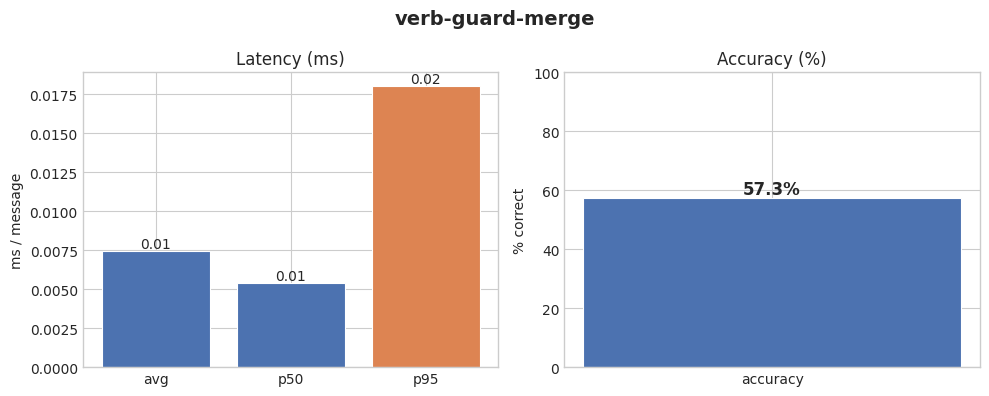

In [133]:
plot_single_result(result4, CONFIG)

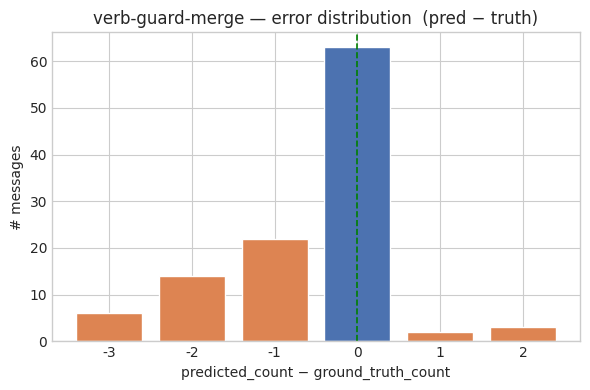

In [134]:
plot_error_distribution(result4, CONFIG)

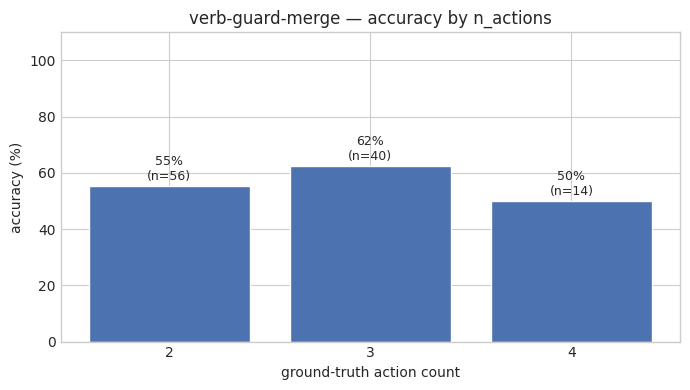

In [135]:
plot_per_class(result4, CONFIG)

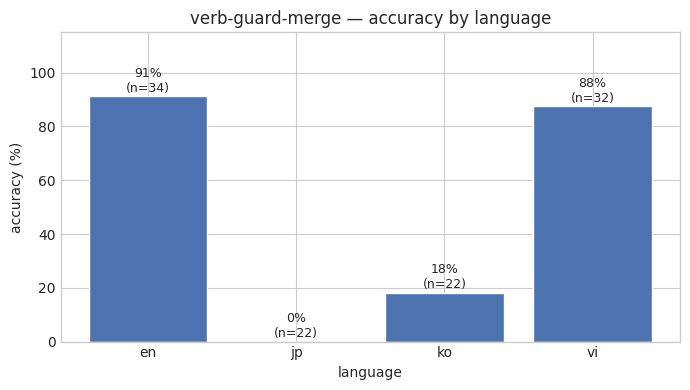

In [136]:
plot_per_lang(result4, CONFIG)

## 16 · Run: Method 5 — cjk-verb-guard

In [137]:
result5 = run_benchmark(
    func         = METHODS[4]["func"],
    name         = METHODS[4]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : cjk-verb-guard
  Accuracy : 61.8%  (68/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.02 ms
    [en] 91.2%  (n=34)
    [jp] 22.7%  (n=22)
    [ko] 18.2%  (n=22)
    [vi] 87.5%  (n=32)
────────────────────────────────────────────────


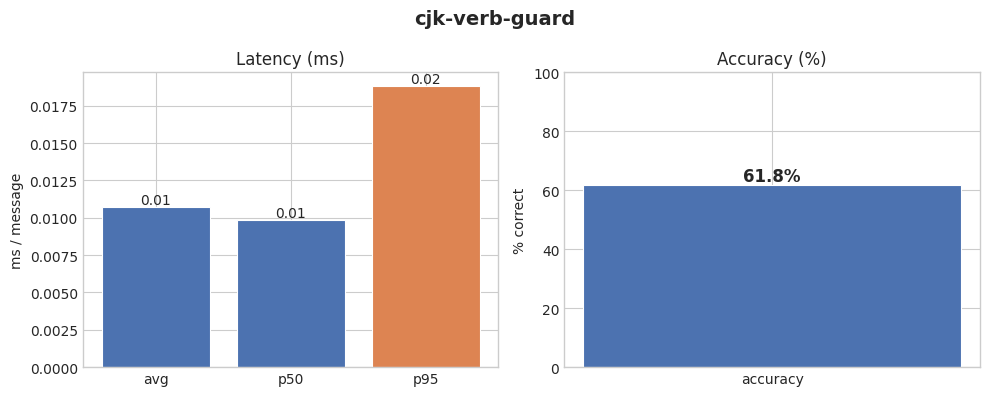

In [138]:
plot_single_result(result5, CONFIG)

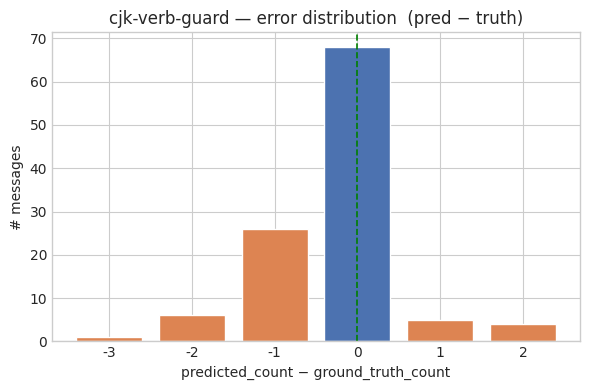

In [139]:
plot_error_distribution(result5, CONFIG)

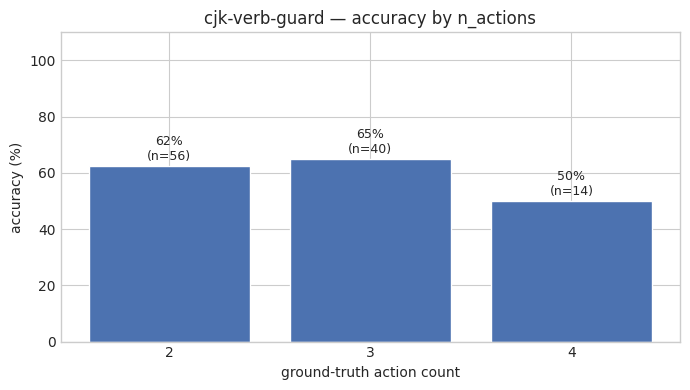

In [140]:
plot_per_class(result5, CONFIG)

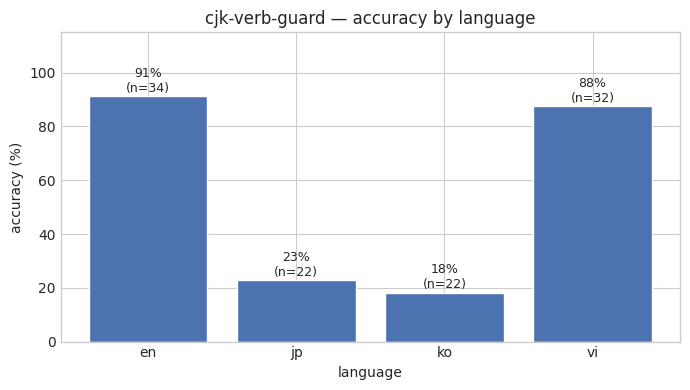

In [141]:
plot_per_lang(result5, CONFIG)

## 17 · Run: Method 6 — spacy-pos

In [142]:
result6 = run_benchmark(
    func         = METHODS[5]["func"],
    name         = METHODS[5]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : spacy-pos
  Accuracy : 73.6%  (81/110)
  Avg time : 1.22 ms/msg
  p50      : 0.02 ms  |  p95 : 4.08 ms
    [en] 91.2%  (n=34)
    [jp] 54.5%  (n=22)
    [ko] 45.5%  (n=22)
    [vi] 87.5%  (n=32)
────────────────────────────────────────────────


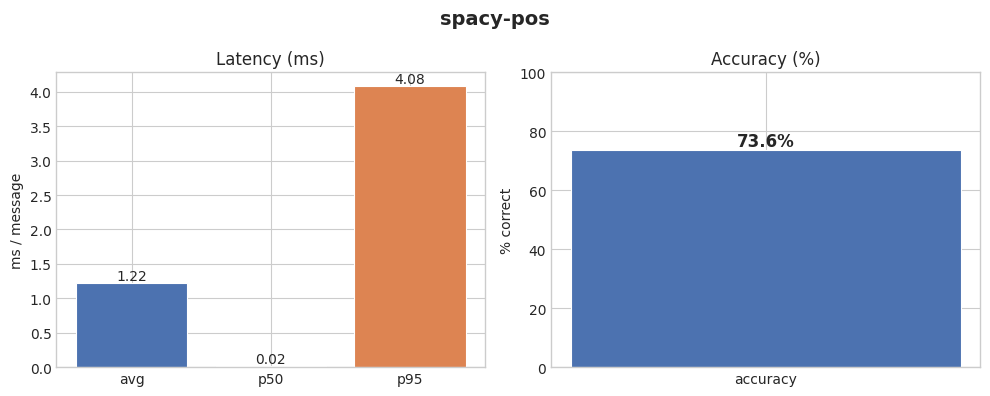

In [143]:
plot_single_result(result6, CONFIG)

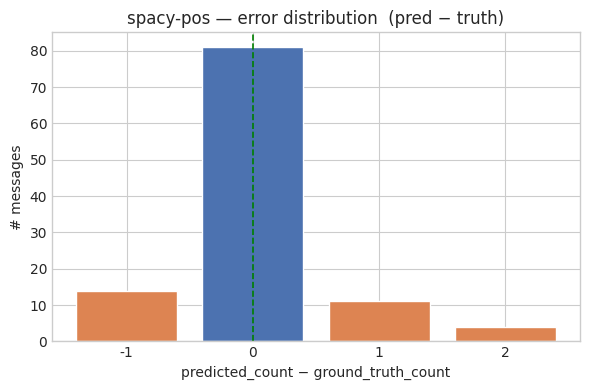

In [144]:
plot_error_distribution(result6, CONFIG)

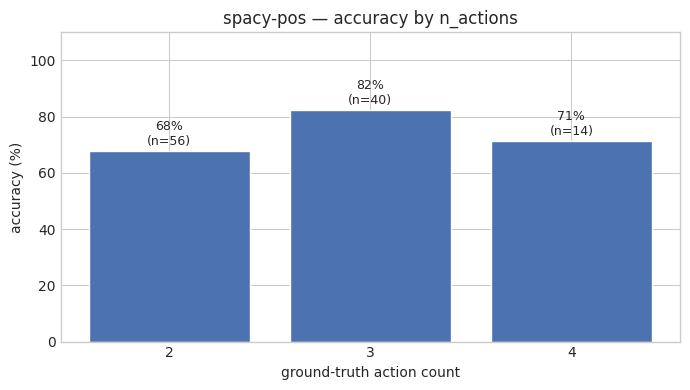

In [145]:
plot_per_class(result6, CONFIG)

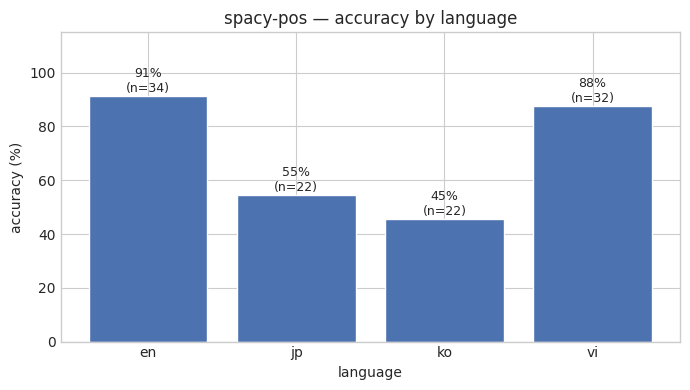

In [146]:
plot_per_lang(result6, CONFIG)

## 18 · Final Comparison

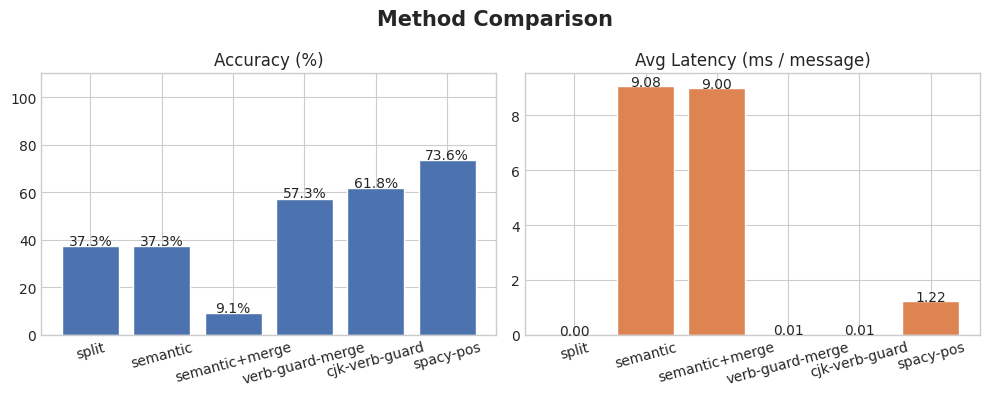

In [147]:
all_results = [result1, result2, result3, result4, result5, result6]

plot_comparison(all_results, CONFIG)

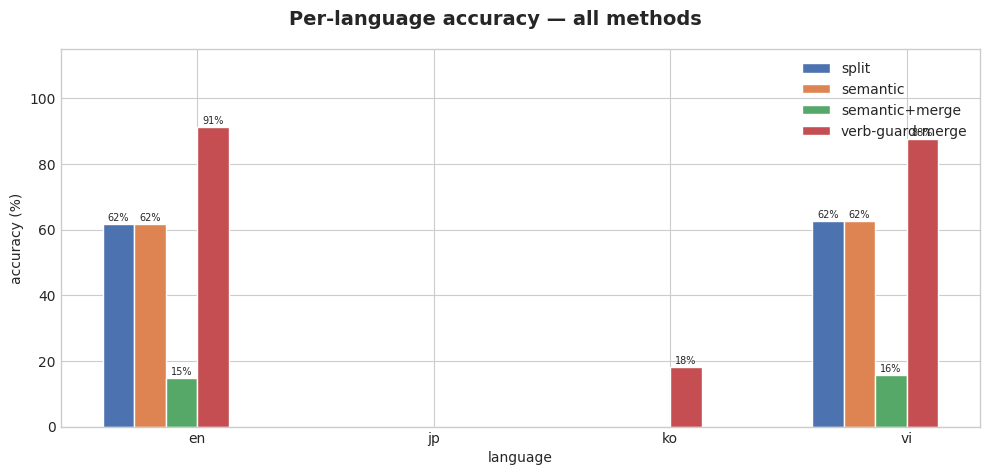

In [148]:
plot_lang_comparison(all_results, CONFIG)

In [149]:
# Summary table
summary_df = pd.DataFrame([
    {
        "method":      r["name"],
        "accuracy_%":  round(r["accuracy"] * 100, 2),
        "avg_ms":      round(r["avg_time_ms"], 3),
        "p50_ms":      round(r["p50_ms"], 3),
        "p95_ms":      round(r["p95_ms"], 3),
    }
    for r in all_results
])
summary_df

,method,accuracy_%,avg_ms,p50_ms,p95_ms
0,split,37.27,0.002,0.002,0.003
1,semantic,37.27,9.076,12.068,19.494
2,semantic+merge,9.09,9.000,11.197,19.240
3,verb-guard-merge,57.27,0.007,0.005,0.018
4,cjk-verb-guard,61.82,0.011,0.010,0.019
5,spacy-pos,73.64,1.221,0.015,4.079


## 19 · Sample-level Inspection

Useful during development — inspect individual predictions for any method.

In [150]:
def inspect_samples(
    result:       dict,
    ground_truth: list[int],
    messages:     list[str],
    n:            int = 10,
    only_errors:  bool = True,
) -> pd.DataFrame:
    """
    Return a DataFrame of individual predictions.

    Parameters
    ----------
    result       : output dict from run_benchmark
    ground_truth : list of expected action counts
    messages     : original raw utterances
    n            : max rows to return
    only_errors  : if True, return only rows where prediction was wrong
    """
    rows = []
    for msg, pred, gt in zip(messages, result["results"], ground_truth):
        correct = len(pred) == gt
        if only_errors and correct:
            continue
        rows.append({
            "message":    msg,
            "predicted":  pred,
            "n_pred":     len(pred),
            "n_gt":       gt,
            "correct":    correct,
        })
        if len(rows) >= n:
            break
    return pd.DataFrame(rows)

In [165]:
# Example: show first 10 errors from method 2
inspect_samples(result6, no_actions, messages, n=10, only_errors=True)

,message,predicted,n_pred,n_gt,correct
0,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,[마이클 잭슨에 대해 말해주고 그의 노래 틀어줘],1,2,False
1,ドアを開けて音楽を流して東京まで案内して,"[ドアを開けて, 音楽を流して, 東京まで案内して]",3,2,False
2,트렁크 열고 음악 틀어줘,[트렁크 열고 음악 틀어줘],1,2,False
3,"트렁크, 앞문, 뒷문 열고 음악 틀어줘",[트렁크 앞문 뒷문 열고 음악 틀어줘],1,2,False
4,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,[마이클 잭슨에 대해 말해주고 그의 노래 틀어줘],1,2,False
5,"트렁크, 문, 선루프 열고 에어컨 켜줘",[트렁크 문 선루프 열고 에어컨 켜줘],1,2,False
6,에어컨 켜고 음악 틀고 농담 말해줘,"[에어컨 켜고, 음악 틀고 농담 말해줘]",2,3,False
7,문 열고 음악 틀고 전화 걸고 길 안내해,"[문 열고, 음악 틀고 전화 걸고, 길 안내해]",3,4,False
8,マイケルジャクソンについて教えて彼の曲を流して,"[マイケルジャクソンについて, 教えて, 彼の曲を流して]",3,2,False
9,トランク、ドア、窓を開けてエアコンをつけて,"[トランク ドア, 窓を開けて, エアコンをつけて]",3,2,False


---
## 20 · Per-Language Accuracy — All Methods

Cross-tabulation: rows = language, columns = method.
Makes it easy to spot which language is hardest for each method,
and whether one method consistently dominates on a specific language.

In [152]:
def build_lang_table(all_results: list[dict]) -> pd.DataFrame:
    """
    Build a wide-format summary table:
      index   = language code
      columns = one accuracy column per method  (e.g. "split_%")
      extra   = "n_total" (sample count, same across methods)

    Parameters
    ----------
    all_results : list of result dicts from run_benchmark (with per_lang set)

    Returns
    -------
    DataFrame sorted by language code.
    """
    frames = []
    for r in all_results:
        if r["per_lang"] is None:
            continue
        pl = r["per_lang"].copy()
        pl = pl.rename(columns={"accuracy": r["name"] + "_%"})
        pl[r["name"] + "_%"] = (pl[r["name"] + "_%"] * 100).round(2)
        frames.append(pl.set_index("lang")[[r["name"] + "_%", "total"]])

    if not frames:
        print("No per_lang data available.")
        return pd.DataFrame()

    # Merge all methods on lang index, keep one "total" column
    merged = frames[0]
    for f in frames[1:]:
        merged = merged.join(f.drop(columns=["total"], errors="ignore"), how="outer")

    merged = merged.rename(columns={"total": "n_total"})
    merged.index.name = "lang"
    return merged.sort_index()

In [153]:
lang_table = build_lang_table(all_results)
lang_table

,split_%,n_total,semantic_%,semantic+merge_%,verb-guard-merge_%,cjk-verb-guard_%,spacy-pos_%
lang,,,,,,,
en,61.76,34,61.76,14.71,91.18,91.18,91.18
jp,0.00,22,0.00,0.00,0.00,22.73,54.55
ko,0.00,22,0.00,0.00,18.18,18.18,45.45
vi,62.50,32,62.50,15.62,87.50,87.50,87.50


In [154]:
# Highlight best method per language
def highlight_best(row: pd.Series) -> list[str]:
    """Bold the highest accuracy in each language row."""
    acc_cols = [c for c in row.index if c.endswith("_%")]
    max_val  = row[acc_cols].max()
    return [
        "font-weight: bold; background-color: #d4edda"
        if (col.endswith("_%") and row[col] == max_val) else ""
        for col in row.index
    ]

acc_cols = [c for c in lang_table.columns if c.endswith("_%")]
lang_table.style.apply(highlight_best, axis=1)

,split_%,n_total,semantic_%,semantic+merge_%,verb-guard-merge_%,cjk-verb-guard_%,spacy-pos_%
lang,,,,,,,
en,61.760000,34,61.760000,14.710000,91.180000,91.180000,91.180000
jp,0.000000,22,0.000000,0.000000,0.000000,22.730000,54.550000
ko,0.000000,22,0.000000,0.000000,18.180000,18.180000,45.450000
vi,62.500000,32,62.500000,15.620000,87.500000,87.500000,87.500000


---
## 21 · Experiment A — `min_words_merge` sweep (methods 3 & 4)

We vary `min_words_merge` from **2 → 6** (step 1) while keeping every
other config value fixed.  A fragment is merged into its predecessor only
when it has **fewer** words than this threshold.

**Hypothesis**: a larger threshold aggressively merges more short
fragments, which may reduce over-splitting but risks under-splitting
when a short fragment is a genuine intent.

Methods under test:
- `method3_semantic_merge`  — semantic split then merge-short
- `method4_verb_guard_merge` — split then verb-guarded merge

In [166]:
SWEEP_MIN_WORDS = list(range(2, 7))   # [2, 3, 4, 5, 6]

# methods we want to run
TARGET_METHOD_NAMES = {
    "semantic+merge",
    "verb-guard-merge",
    "cjk-verb-guard",
    "spacy-pos",
}

# filter methods 3,4,5,6 from METHODS
TARGET_METHODS = [
    m for m in METHODS
    if m["name"] in TARGET_METHOD_NAMES
]

# results container
exp_a_results: dict[str, list[dict]] = {
    m["name"]: [] for m in TARGET_METHODS
}

# sweep loop
for mw in SWEEP_MIN_WORDS:
    sweep_cfg = {
        **CONFIG,
        "min_words_merge": mw,
    }

    for m in TARGET_METHODS:

        func = m["func"]
        label = m["name"]

        r = run_benchmark(
            func=func,
            name=f"{label}  min_words={mw}",
            cfg=sweep_cfg,
            messages=messages,
            ground_truth=no_actions,
            verbose=True,
        )

        r["min_words_merge"] = mw

        exp_a_results[label].append(r)

────────────────────────────────────────────────
  Method   : semantic+merge  min_words=2
  Accuracy : 47.3%  (52/110)
  Avg time : 10.16 ms/msg
  p50      : 11.36 ms  |  p95 : 30.02 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : verb-guard-merge  min_words=2
  Accuracy : 47.3%  (52/110)
  Avg time : 0.01 ms/msg
  p50      : 0.00 ms  |  p95 : 0.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : cjk-verb-guard  min_words=2
  Accuracy : 62.7%  (69/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : spacy-pos  min_words=2
  Accuracy : 67.3%  (74/110)
  Avg time : 1.22 ms/msg
  p50      : 0.02 ms  |  p95 : 4.51 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic+m

/tmp/ipykernel_531615/493345777.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


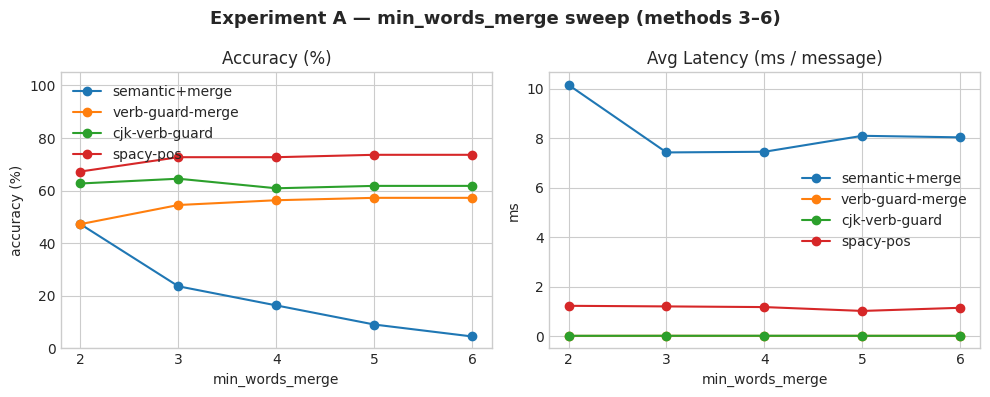

In [168]:
# ── Plot Experiment A ──────────────────────────────────────────────────────
def plot_exp_a(
    exp_results: dict[str, list[dict]],
    sweep_values: list[int],
    cfg: dict,
) -> None:
    """
    Line chart: accuracy and avg latency vs min_words_merge,
    one line per method.
    """

    _apply_style(cfg)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(cfg["fig_width"], cfg["fig_height"])
    )

    fig.suptitle(
        "Experiment A — min_words_merge sweep (methods 3–6)",
        fontsize=13,
        fontweight="bold",
    )

    # generate enough colors automatically
    cmap = plt.cm.get_cmap("tab10")

    for i, (label, results) in enumerate(exp_results.items()):

        color = cmap(i)

        accs = [r["accuracy"] * 100 for r in results]
        lats = [r["avg_time_ms"] for r in results]

        axes[0].plot(
            sweep_values,
            accs,
            marker="o",
            label=label,
            color=color,
        )

        axes[1].plot(
            sweep_values,
            lats,
            marker="o",
            label=label,
            color=color,
        )

    axes[0].set_title("Accuracy (%)")
    axes[0].set_xlabel("min_words_merge")
    axes[0].set_ylabel("accuracy (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_xticks(sweep_values)
    axes[0].legend()

    axes[1].set_title("Avg Latency (ms / message)")
    axes[1].set_xlabel("min_words_merge")
    axes[1].set_ylabel("ms")
    axes[1].set_xticks(sweep_values)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_exp_a(exp_a_results, SWEEP_MIN_WORDS, CONFIG)

In [157]:
# ── Summary table — Experiment A ──────────────────────────────────────────
exp_a_rows = []
for label, results in exp_a_results.items():
    for r in results:
        exp_a_rows.append({
            "method":          label,
            "min_words_merge": r["min_words_merge"],
            "accuracy_%":      round(r["accuracy"] * 100, 2),
            "avg_ms":          round(r["avg_time_ms"], 3),
            "p50_ms":          round(r["p50_ms"], 3),
            "p95_ms":          round(r["p95_ms"], 3),
        })

exp_a_df = (
    pd.DataFrame(exp_a_rows)
    .sort_values(["method", "min_words_merge"])
    .reset_index(drop=True)
)
exp_a_df

,method,min_words_merge,accuracy_%,avg_ms,p50_ms,p95_ms
0,semantic+merge,2,47.27,9.874,12.279,20.569
1,semantic+merge,3,23.64,8.881,11.069,18.585
2,semantic+merge,4,16.36,8.219,11.341,17.572
3,semantic+merge,5,9.09,8.117,11.042,17.656
4,semantic+merge,6,4.55,8.378,11.105,18.289
5,verb-guard-merge,2,47.27,0.005,0.005,0.012
6,verb-guard-merge,3,54.55,0.011,0.007,0.025
7,verb-guard-merge,4,56.36,0.005,0.005,0.012
8,verb-guard-merge,5,57.27,0.005,0.004,0.012
9,verb-guard-merge,6,57.27,0.009,0.007,0.028


In [158]:
# Best min_words_merge per method (by accuracy)
exp_a_df.loc[
    exp_a_df.groupby("method")["accuracy_%"].idxmax()
][["method", "min_words_merge", "accuracy_%", "avg_ms"]]

,method,min_words_merge,accuracy_%,avg_ms
0,semantic+merge,2,47.27,9.874
8,verb-guard-merge,5,57.27,0.005


---
## 22 · Experiment B — `similarity_threshold` sweep (methods 2 & 3)

We vary `similarity_threshold` across **[0.7, 0.8, 0.9]** while keeping
every other config value fixed.

A higher threshold means two fragments must be *more* similar for them to
be merged — i.e. the method becomes more conservative and splits more.

Methods under test (those that use embeddings):
- `method2_semantic`       — semantic split + pronoun resolution
- `method3_semantic_merge` — method 2 + short-fragment merging

In [169]:
SWEEP_SIM_THRESHOLDS = [0.7, 0.8, 0.9]

TARGET_METHOD_NAMES = {
    "semantic",
    "semantic+merge",
    "verb-guard-merge",
    "cjk-verb-guard",
    "spacy-pos",
}

TARGET_METHODS = [
    m for m in METHODS
    if m["name"] in TARGET_METHOD_NAMES
]

exp_b_results: dict[str, list[dict]] = {
    m["name"]: [] for m in TARGET_METHODS
}

for thresh in SWEEP_SIM_THRESHOLDS:

    sweep_cfg = {
        **CONFIG,
        "similarity_threshold": thresh,
    }

    for m in TARGET_METHODS:

        func = m["func"]
        label = m["name"]

        r = run_benchmark(
            func=func,
            name=f"{label}  sim={thresh}",
            cfg=sweep_cfg,
            messages=messages,
            ground_truth=no_actions,
            verbose=True,
        )

        r["similarity_threshold"] = thresh

        exp_b_results[label].append(r)

────────────────────────────────────────────────
  Method   : semantic  sim=0.7
  Accuracy : 37.3%  (41/110)
  Avg time : 9.81 ms/msg
  p50      : 10.52 ms  |  p95 : 32.68 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic+merge  sim=0.7
  Accuracy : 9.1%  (10/110)
  Avg time : 8.31 ms/msg
  p50      : 11.03 ms  |  p95 : 15.93 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : verb-guard-merge  sim=0.7
  Accuracy : 57.3%  (63/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : cjk-verb-guard  sim=0.7
  Accuracy : 61.8%  (68/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.02 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : spacy-pos  sim=0.7
  Accura

/tmp/ipykernel_531615/601319861.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


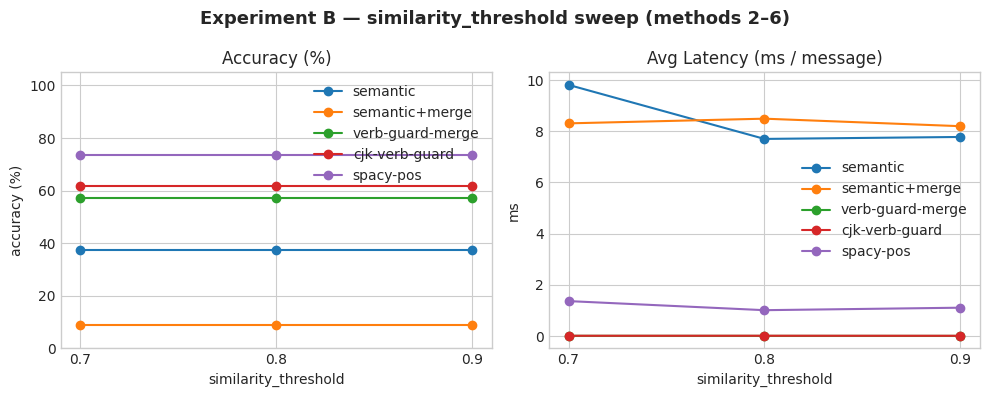

In [170]:
# ── Plot Experiment B ──────────────────────────────────────────────────────
def plot_exp_b(
    exp_results: dict[str, list[dict]],
    sweep_values: list[float],
    cfg: dict,
) -> None:

    _apply_style(cfg)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(cfg["fig_width"], cfg["fig_height"]),
    )

    fig.suptitle(
        "Experiment B — similarity_threshold sweep (methods 2–6)",
        fontsize=13,
        fontweight="bold",
    )

    cmap = plt.cm.get_cmap("tab10")

    for i, (label, results) in enumerate(exp_results.items()):

        color = cmap(i)

        accs = [r["accuracy"] * 100 for r in results]
        lats = [r["avg_time_ms"] for r in results]

        axes[0].plot(
            sweep_values,
            accs,
            marker="o",
            label=label,
            color=color,
        )

        axes[1].plot(
            sweep_values,
            lats,
            marker="o",
            label=label,
            color=color,
        )

    axes[0].set_title("Accuracy (%)")
    axes[0].set_xlabel("similarity_threshold")
    axes[0].set_ylabel("accuracy (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_xticks(sweep_values)
    axes[0].legend()

    axes[1].set_title("Avg Latency (ms / message)")
    axes[1].set_xlabel("similarity_threshold")
    axes[1].set_ylabel("ms")
    axes[1].set_xticks(sweep_values)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_exp_b(exp_b_results, SWEEP_SIM_THRESHOLDS, CONFIG)